In [28]:
import numpy as np
import matplotlib.pyplot as plt

from weather.config import WeatherConfig
from weather.dataset import build_dataset
from weather.normalization import normalize_global

from mlp.mlp import MLP
from mlp.utils import plot_loss


In [29]:
SEED = 42
np.random.seed(SEED)

experiments = {
    "wind_6plus_classification": {
        "task": "binary",
        "losses": ["binary_cross_entropy"],
        "activation": "gelu",
        # "activation": "sigmoid",
        "learning_rate": 0.01,
        "hidden_layers": [64, 64, 64, 64, 64],
        "epochs": [400],
        # "epochs": [20],
        "optimizer": "momentum",
        "adaptive_lr": True,
        "batching": {
            "minibatch_auto": {
                "batch_size": "auto",
                "shuffle": False,
            },
        },
        "early_stopping": True,
        "patience": 20,
    }
}


In [30]:
base_cfg = WeatherConfig(
    data_dir="../data",
    split="train",
    target="wind_speed",
    window_size=3,
    skip_day=True,
    normalization="global",
    encode_wind_direction=True,
    max_missing_ratio_per_day=0.3,
    target_mode="binary",
    target_threshold=6.0,
)

base_cfg.input_variables = [
    "temperature",
    "humidity",
    "pressure",
    "wind_speed",
    "wind_direction",
]

base_cfg.aggregations = {
    "temperature": ["mean", "min", "max"],
    "humidity": ["mean", "min", "max"],
    "pressure": ["mean", "min", "max"],
    "wind_speed": ["mean", "max"],
    "wind_direction": ["mean"],
}

base_cfg.cities = ["Vancouver", "Portland", "San Francisco", "Seattle", "Los Angeles", "San Diego", "Las Vegas"]


In [31]:
# %pdb on

from copy import deepcopy
from mlp.mlp import MLP
from mlp.utils import plot_loss, plot_accuracy
from weather.dataset import build_dataset
from weather.normalization import normalize_global

results = {}

# for mode in ["flatten", "aggregate"]:
for mode in ["flatten"]:
    print("\n" + "=" * 80)
    print(f"WINDOW AGGREGATION MODE: {mode.upper()}")
    print("=" * 80)

    cfg = deepcopy(base_cfg)
    cfg.window_aggregation = mode

    # --- TRAIN DATASET ---
    print("\nBuilding TRAIN dataset...")
    cfg.split = "train"
    X_train, y_train = build_dataset(cfg, verbose=False)
    X_train, mu, sigma = normalize_global(X_train)

    # --- TEST DATASET ---
    print("\nBuilding TEST dataset...")
    cfg.split = "test"
    X_test, y_test = build_dataset(cfg, verbose=False)
    X_test = (X_test - mu) / sigma  # ta sama normalizacja

    print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
    print(f"Test  shape: X={X_test.shape}, y={y_test.shape}")

    results[mode] = {}



WINDOW AGGREGATION MODE: FLATTEN

Building TRAIN dataset...


Vancouver | windows: 100%|██████████| 1518/1518 [00:05<00:00, 278.29it/s]
Portland | windows: 100%|██████████| 1518/1518 [00:06<00:00, 243.30it/s]
San Francisco | windows: 100%|██████████| 1518/1518 [00:06<00:00, 249.88it/s]
Seattle | windows: 100%|██████████| 1518/1518 [00:06<00:00, 252.60it/s]
Los Angeles | windows: 100%|██████████| 1518/1518 [00:06<00:00, 249.52it/s]
San Diego | windows: 100%|██████████| 1518/1518 [00:06<00:00, 251.27it/s]
Las Vegas | windows: 100%|██████████| 1518/1518 [00:06<00:00, 249.42it/s]



Building TEST dataset...


Vancouver | windows: 100%|██████████| 361/361 [00:01<00:00, 280.41it/s]
Portland | windows: 100%|██████████| 361/361 [00:01<00:00, 254.28it/s]
San Francisco | windows: 100%|██████████| 361/361 [00:01<00:00, 273.11it/s]
Seattle | windows: 100%|██████████| 361/361 [00:01<00:00, 251.04it/s]
Los Angeles | windows: 100%|██████████| 361/361 [00:01<00:00, 250.37it/s]
San Diego | windows: 100%|██████████| 361/361 [00:01<00:00, 248.62it/s]
Las Vegas | windows: 100%|██████████| 361/361 [00:01<00:00, 235.10it/s]

Train shape: X=(10245, 39), y=(10245, 1)
Test  shape: X=(2447, 39), y=(2447, 1)



--- EXPERIMENT: wind_6plus_classification ---

Loss=binary_cross_entropy, Epochs=400, Activation=gelu, Optimizer=momentum
>>> Initializing MLP...
Layer sizes: [39, 64, 64, 64, 64, 64, 1], Task: binary, Activation: gelu, Optimizer: momentum
>>> Version 16 (mini-batch + early stopping)...


Training:  10%|▉         | 39/400 [00:23<03:35,  1.67it/s, acc=0.7587, loss=0.4920, lr=0.00675729]


Early stopping at epoch 40, best val_loss=0.530469, train_acc=0.7587, val_acc=0.7376 after 20 epochs without improvement.
Training finished in 23.31 seconds
Test accuracy : 0.7103
Test precision: 0.7653
Test recall   : 0.8695


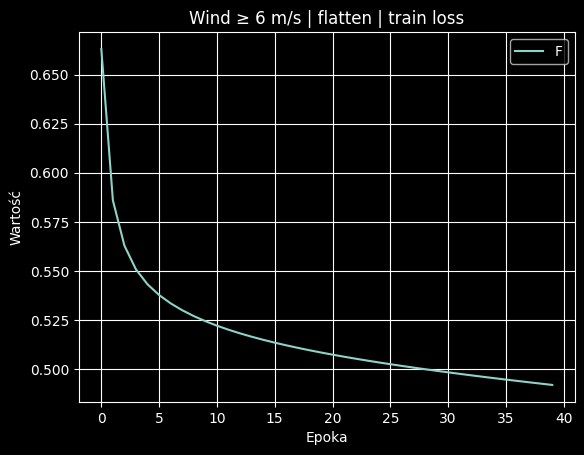

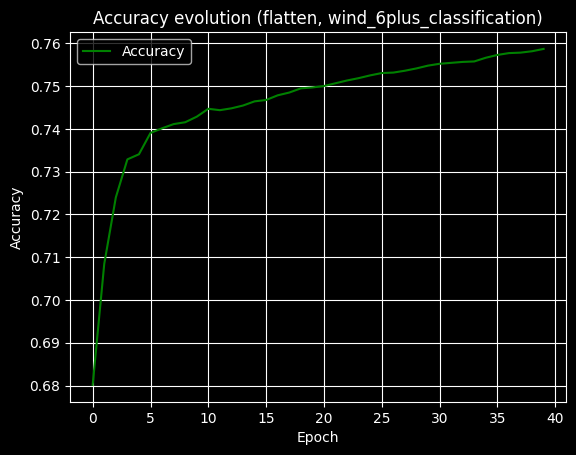

In [32]:
for mode in ["flatten"]:
    for exp_name, exp in experiments.items():
        print(f"\n--- EXPERIMENT: {exp_name} ---")

        n_inputs = X_train.shape[1]

        for loss_name in exp["losses"]:
            for n_epochs in exp["epochs"]:

                print(
                    f"\nLoss={loss_name}, "
                    f"Epochs={n_epochs}, "
                    f"Activation={exp['activation']}, "
                    f"Optimizer={exp['optimizer']}"
                )

                model = MLP(
                    layer_sizes=[n_inputs, *exp["hidden_layers"], 1],
                    task=exp["task"],
                    activation=exp["activation"],
                    learning_rate=exp["learning_rate"],
                    seed=SEED,
                    loss=loss_name,
                    optimizer=exp["optimizer"],
                    adaptive_lr=exp["adaptive_lr"],
                )

                history, _, acc_hist = model.fit(
                    X_train,
                    y_train,
                    epochs=n_epochs,
                    batch_size=exp["batching"]["minibatch_auto"]["batch_size"],
                    shuffle=exp["batching"]["minibatch_auto"]["shuffle"],
                    verbose=True,
                    use_tqdm=True,
                    early_stopping=exp["early_stopping"],
                    patience=exp["patience"],
                )

                # ===================== TEST EVALUATION =====================
                y_pred = model.predict(X_test)

                acc = np.mean(y_pred == y_test)

                tp = np.sum((y_pred == 1) & (y_test == 1))
                fp = np.sum((y_pred == 1) & (y_test == 0))
                fn = np.sum((y_pred == 0) & (y_test == 1))

                precision = tp / (tp + fp + 1e-8)
                recall = tp / (tp + fn + 1e-8)

                print(f"Test accuracy : {acc:.4f}")
                print(f"Test precision: {precision:.4f}")
                print(f"Test recall   : {recall:.4f}")

                results[mode][exp_name] = {
                    "train_loss": history,
                    "train_acc": acc_hist,
                    "test_accuracy": acc,
                    "test_precision": precision,
                    "test_recall": recall,
                }

                plot_loss(
                    history,
                    title=f"Wind ≥ 6 m/s | {mode} | train loss"
                )

                plot_accuracy(acc_hist, title=f"Accuracy evolution ({mode}, {exp_name})")

# %pdb off
